## Tumor Misclassification: Case 2 Defense

I am investigating why the random forest classified Patient X as benign and how that decision fits its learned patterns and the broader dataset.

The scenario says Patient X was not referred for a biopsy and was later diagnosed as malignant. My defense focuses on whether the classification can be explained by the model's evidence. I do not assume that explaining the prediction proves it was correct or validates the decision to withhold a biopsy.

I use global SHAP importance, local SHAP, and local LIME. **The class mapping throughout this notebook is `0 = malignant; 1 = benign`.**

### 1. Dataset Loading and Initial Check

First I load the supplied breast cancer dataset and inspect its size, class balance, missing values, and feature summaries. I use Case 2-specific variable names so the other starter cases cannot overwrite this analysis.

In [1]:
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from IPython.display import display
from lime.lime_tabular import LimeTabularExplainer
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score
from sklearn.model_selection import train_test_split

plt.style.use("default")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 100)
RANDOM_STATE = 42
BENIGN = 1
MALIGNANT = 0
BENIGN_COLOR = "#4c78a8"
MALIGNANT_COLOR = "#f58518"

print("Python:", sys.version.split()[0])
display(pd.Series({name: version(name) for name in ["numpy", "pandas", "scikit-learn", "shap", "lime", "matplotlib"]}, name="Installed version").to_frame())

Python: 3.11.16


,Installed version
numpy,1.26.4
pandas,3.0.5
scikit-learn,1.9.1
shap,0.46.0
lime,0.2.0.1
matplotlib,3.11.2


In [2]:
data_bc = load_breast_cancer()
X_bc = pd.DataFrame(data_bc.data, columns=data_bc.feature_names)
y_bc = pd.Series(data_bc.target, name="target")
df_bc = X_bc.assign(target=y_bc)
class_names_bc = list(data_bc.target_names)
assert class_names_bc == ["malignant", "benign"]

summary_bc = pd.DataFrame({
    "check": ["Observations", "Predictor features", "Missing predictor values", "Malignant cases (0)", "Benign cases (1)"],
    "value": [len(X_bc), X_bc.shape[1], int(X_bc.isna().sum().sum()), int((y_bc == 0).sum()), int((y_bc == 1).sum())],
})
display(summary_bc)
display(df_bc.head())
display(X_bc.describe().T[["mean", "std", "min", "50%", "max"]].round(4))

,check,value
0,Observations,569
1,Predictor features,30
2,Missing predictor values,0
3,Malignant cases (0),212
4,Benign cases (1),357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


,mean,std,min,50%,max
mean radius,14.1273,3.5240,6.9810,13.3700,28.1100
mean texture,19.2896,4.3010,9.7100,18.8400,39.2800
mean perimeter,91.9690,24.2990,43.7900,86.2400,188.5000
mean area,654.8891,351.9141,143.5000,551.1000,2501.0000
mean smoothness,0.0964,0.0141,0.0526,0.0959,0.1634
mean compactness,0.1043,0.0528,0.0194,0.0926,0.3454
mean concavity,0.0888,0.0797,0.0000,0.0615,0.4268
mean concave points,0.0489,0.0388,0.0000,0.0335,0.2012
mean symmetry,0.1812,0.0274,0.1060,0.1792,0.3040
mean fractal dimension,0.0628,0.0071,0.0500,0.0615,0.0974


,Count,Proportion
Malignant (0),212,0.373
Benign (1),357,0.627


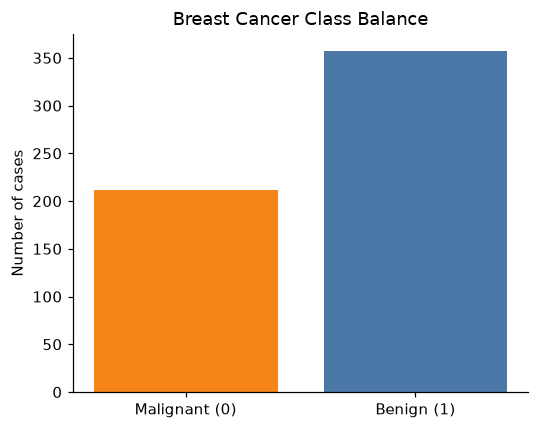

In [3]:
class_balance_bc = y_bc.value_counts().reindex([0, 1]).rename_axis("Class").to_frame("Count")
class_balance_bc.index = ["Malignant (0)", "Benign (1)"]
class_balance_bc["Proportion"] = class_balance_bc["Count"] / len(y_bc)
display(class_balance_bc.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_balance_bc.index, class_balance_bc["Count"], color=[MALIGNANT_COLOR, BENIGN_COLOR])
ax.set_title("Breast Cancer Class Balance")
ax.set_ylabel("Number of cases")
plt.tight_layout()
plt.show()

The dataset contains 569 observations and 30 numeric predictors, with no missing predictor values. There are 357 benign cases and 212 malignant cases, so benign is the larger class. This gives context for Patient X's prediction, but class balance alone cannot explain an individual decision.

The dataset describes measurements of cell nuclei from fine needle aspirate images. It is a teaching classification dataset, not a validation study of a pre-biopsy referral workflow. [Dataset description](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset)

### 2. Original Model and Patient X

I keep the starter's 80/20 split, `random_state=42`, and default random forest. I do not add stratification, tune the model, or change Patient X's measurements. There are no missing values to impute, and I keep all 30 predictors.

In [4]:
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=RANDOM_STATE,
)
model_bc = RandomForestClassifier(random_state=RANDOM_STATE)
model_bc.fit(X_train_bc, y_train_bc)
benign_col_bc = int(np.flatnonzero(model_bc.classes_ == BENIGN)[0])
malignant_col_bc = int(np.flatnonzero(model_bc.classes_ == MALIGNANT)[0])
print(f"Training rows: {len(X_train_bc)}; test rows: {len(X_test_bc)}")
print(f"Trees: {model_bc.n_estimators}; class order: {model_bc.classes_}")

Training rows: 455; test rows: 114
Trees: 100; class order: [0 1]


In [5]:
focus_instance_bc = pd.DataFrame([{
    "mean radius": 13.80,
    "mean texture": 15.79,
    "mean perimeter": 90.43,
    "mean area": 584.1,
    "mean smoothness": 0.1007,
    "mean compactness": 0.1280,
    "mean concavity": 0.07789,
    "mean concave points": 0.05069,
    "mean symmetry": 0.1662,
    "mean fractal dimension": 0.06566,
    "radius error": 0.4101,
    "texture error": 1.074,
    "perimeter error": 2.635,
    "area error": 40.14,
    "smoothness error": 0.00541,
    "compactness error": 0.02204,
    "concavity error": 0.01664,
    "concave points error": 0.01185,
    "symmetry error": 0.02095,
    "fractal dimension error": 0.004902,
    "worst radius": 16.57,
    "worst texture": 20.86,
    "worst perimeter": 110.3,
    "worst area": 812.4,
    "worst smoothness": 0.1411,
    "worst compactness": 0.3542,
    "worst concavity": 0.2779,
    "worst concave points": 0.1383,
    "worst symmetry": 0.2589,
    "worst fractal dimension": 0.1030
}])

assert set(focus_instance_bc.columns) == set(X_train_bc.columns)
focus_instance_bc = focus_instance_bc.loc[:, X_train_bc.columns]
assert focus_instance_bc.columns.equals(X_train_bc.columns)
assert np.isfinite(focus_instance_bc.to_numpy()).all()
print("Patient X: all 30 feature names and their order match the training data.")
display(focus_instance_bc.T.rename(columns={0: "Patient X value"}))

Patient X: all 30 feature names and their order match the training data.


,Patient X value
mean radius,13.800000
mean texture,15.790000
mean perimeter,90.430000
mean area,584.100000
mean smoothness,0.100700
mean compactness,0.128000
mean concavity,0.077890
mean concave points,0.050690
mean symmetry,0.166200
mean fractal dimension,0.065660


### 3. Model Performance and Patient X's Prediction

I evaluate the untouched test set before interpreting Patient X. I explicitly calculate recall for **malignant, class 0**, because a malignant case classified as benign is the error most relevant to the scenario.

Test accuracy: 96.49%
Malignant cases classified as benign: 3 / 43
Malignant-class recall: 93.02%

               precision    recall  f1-score   support

Malignant (0)      0.976     0.930     0.952        43
   Benign (1)      0.959     0.986     0.972        71

     accuracy                          0.965       114
    macro avg      0.967     0.958     0.962       114
 weighted avg      0.965     0.965     0.965       114



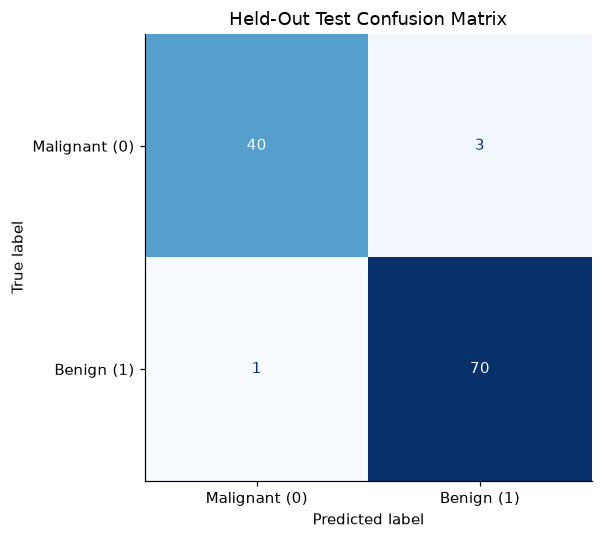

In [6]:
test_pred_bc = model_bc.predict(X_test_bc)
cm_bc = confusion_matrix(y_test_bc, test_pred_bc, labels=[0, 1])
accuracy_bc = accuracy_score(y_test_bc, test_pred_bc)
malignant_recall_bc = recall_score(y_test_bc, test_pred_bc, pos_label=MALIGNANT)
missed_malignant_bc = int(cm_bc[0, 1])
print(f"Test accuracy: {accuracy_bc:.2%}")
print(f"Malignant cases classified as benign: {missed_malignant_bc} / {cm_bc[0].sum()}")
print(f"Malignant-class recall: {malignant_recall_bc:.2%}")
print()
print(classification_report(y_test_bc, test_pred_bc, labels=[0, 1], target_names=["Malignant (0)", "Benign (1)"], digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_bc, display_labels=["Malignant (0)", "Benign (1)"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Held-Out Test Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows 40 of 43 malignant cases correctly identified, while 3 were classified as benign. The model also correctly classified 70 of 71 benign cases. Accuracy is 96.49%, but malignant recall is 93.02%, so the high overall accuracy does not eliminate the type of error described in Patient X's scenario.

For the defense, this supports the model's ability to learn useful classification patterns on this split. It also shows a concrete limit: 6.98% of the malignant test cases were missed. This small held-out sample does not establish performance in a clinical setting.

In [7]:
patient_pred_bc = int(model_bc.predict(focus_instance_bc)[0])
patient_proba_bc = model_bc.predict_proba(focus_instance_bc)[0]
patient_benign_bc = float(patient_proba_bc[benign_col_bc])
patient_malignant_bc = float(patient_proba_bc[malignant_col_bc])
patient_prediction_bc = pd.DataFrame({
    "Prediction output": ["Predicted class", "Model-predicted probability of benign", "Model-predicted probability of malignant"],
    "Value": [f"{class_names_bc[patient_pred_bc]} ({patient_pred_bc})", f"{patient_benign_bc:.2%}", f"{patient_malignant_bc:.2%}"],
})
display(patient_prediction_bc)

,Prediction output,Value
0,Predicted class,benign (1)
1,Model-predicted probability of benign,85.00%
2,Model-predicted probability of malignant,15.00%


The model predicts **benign with probability 0.85**, compared with 0.15 for malignant. It favors benign by a substantial margin rather than making a near-tie decision, but these are model-predicted probabilities, not clinically validated estimates of Patient X's outcome.

The later malignant diagnosis comes from the scenario. Patient X's code supplies measurements without a separate observed outcome record, so I do not add this scenario case to the held-out accuracy calculation.

### 4. Global SHAP Feature Importance

I explain the benign-class probability using a Tree SHAP explainer with 100 training rows sampled at seed 42 as the background. I explicitly set `feature_perturbation="interventional"` and `model_output="probability"`, and reuse this explainer for Patient X. This defines the reference distribution and output scale. [TreeExplainer documentation](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html)

I rank features by their mean absolute SHAP contribution across all 114 test cases. This is global importance over these analyzed cases; it does not show whether a feature supports Patient X's prediction.

,Feature,Mean absolute SHAP
23,worst area,0.0733
27,worst concave points,0.0610
22,worst perimeter,0.0468
7,mean concave points,0.0426
20,worst radius,0.0398
26,worst concavity,0.0296
6,mean concavity,0.0288
21,worst texture,0.0210
13,area error,0.0208
3,mean area,0.0177


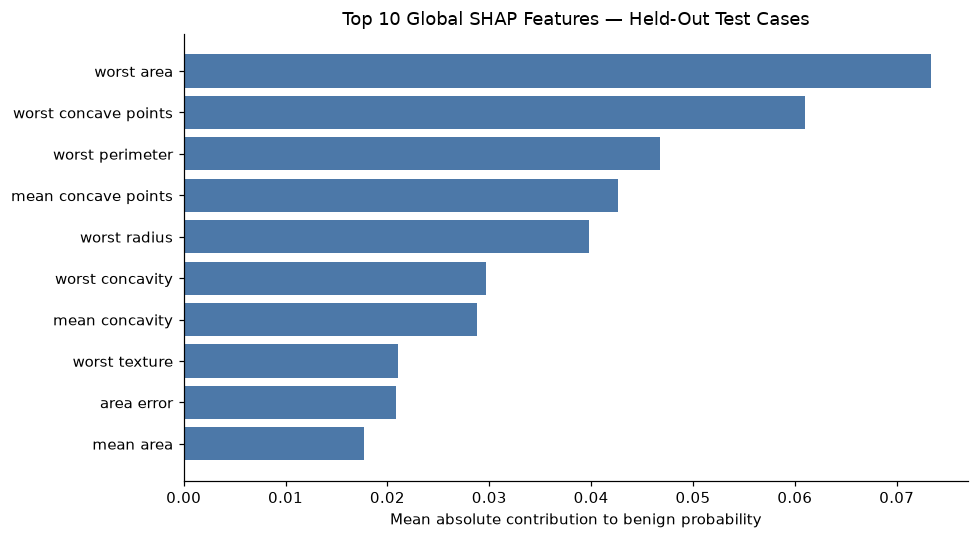

In [8]:
background_bc = X_train_bc.sample(n=100, random_state=RANDOM_STATE)
shap_explainer_bc = shap.TreeExplainer(
    model_bc, data=background_bc,
    feature_perturbation="interventional", model_output="probability",
)
shap_test_all_bc = shap_explainer_bc(X_test_bc)
assert shap_test_all_bc.values.shape == (len(X_test_bc), X_test_bc.shape[1], len(model_bc.classes_))
shap_test_benign_bc = shap_test_all_bc[:, :, benign_col_bc]
np.testing.assert_allclose(
    shap_test_benign_bc.base_values + shap_test_benign_bc.values.sum(axis=1),
    model_bc.predict_proba(X_test_bc)[:, benign_col_bc], atol=1e-6, rtol=0,
)
global_importance_bc = pd.DataFrame({
    "Feature": X_train_bc.columns,
    "Mean absolute SHAP": np.abs(shap_test_benign_bc.values).mean(axis=0),
}).sort_values("Mean absolute SHAP", ascending=False)
display(global_importance_bc.head(10).round(4))

top_global_bc = global_importance_bc.head(10).sort_values("Mean absolute SHAP")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_global_bc["Feature"], top_global_bc["Mean absolute SHAP"], color=BENIGN_COLOR)
ax.set_title("Top 10 Global SHAP Features — Held-Out Test Cases")
ax.set_xlabel("Mean absolute contribution to benign probability")
plt.tight_layout()
plt.show()

`worst area` has the largest mean absolute SHAP contribution (0.0733), followed by `worst concave points` (0.0610) and `worst perimeter` (0.0468). The global chart shows that size and concavity-related measurements are prominent in the model's predictions across the test cases.

For Patient X, this gives a reason to examine those features carefully, but it does not say which direction they push this particular prediction. A globally important feature can support benign for one case and oppose it for another.

### 5. Local SHAP Explanation for Patient X

Now I explain Patient X with the same background and class selection. Positive SHAP values increase the benign probability relative to the background baseline; negative values decrease it.

The waterfall starts at the baseline and adds feature contributions to reach the prediction. Its default red bars increase the selected output, so here red means **toward benign**, not toward malignant. [Waterfall documentation](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html)

Largest absolute contributions:


,Feature,Patient X value,SHAP contribution,Direction
21,worst texture,20.86000,0.04390,Toward benign
27,worst concave points,0.13830,0.03567,Toward benign
23,worst area,812.40000,0.02781,Toward benign
6,mean concavity,0.07789,0.02358,Toward benign
20,worst radius,16.57000,0.02286,Toward benign
1,mean texture,15.79000,0.01746,Toward benign
7,mean concave points,0.05069,0.01382,Toward benign
2,mean perimeter,90.43000,0.01308,Toward benign
0,mean radius,13.80000,0.01178,Toward benign
3,mean area,584.10000,0.01145,Toward benign


Strongest opposing contributions (shown separately so they are not hidden):


,Feature,Patient X value,SHAP contribution,Direction
22,worst perimeter,110.3000,-0.01016,Away from benign
29,worst fractal dimension,0.1030,-0.00948,Away from benign
24,worst smoothness,0.1411,-0.00364,Away from benign


All positive contributions: +0.26945
All negative contributions: -0.02645
Baseline: 0.607000
Sum of ALL 30 contributions: +0.243000
Reconstructed probability: 0.850000; model: 0.850000
Absolute reconstruction error: 1.41e-09


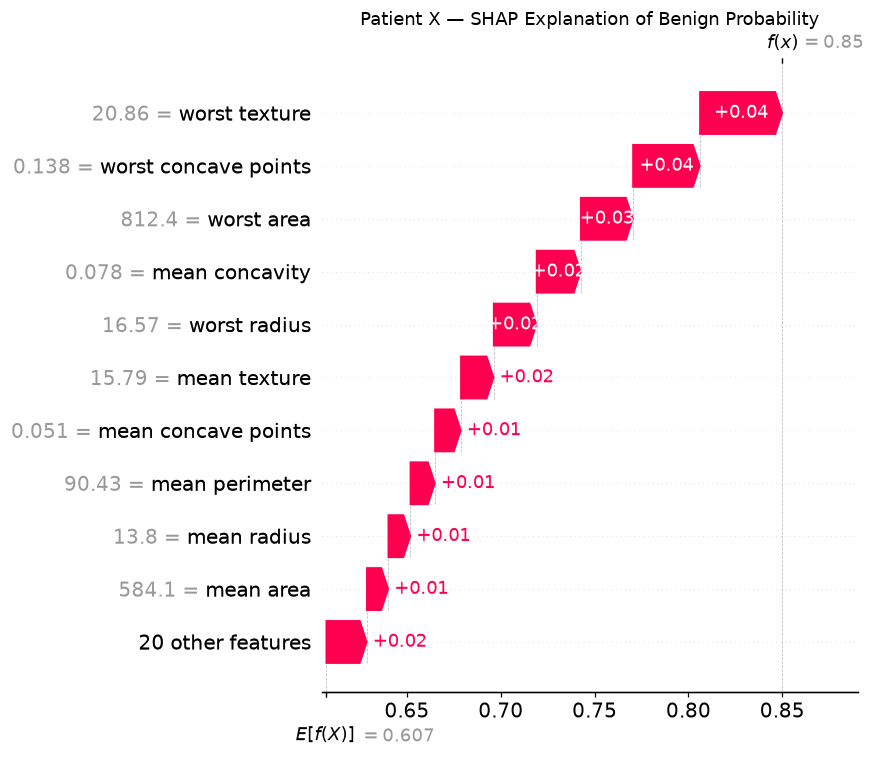

In [9]:
shap_patient_all_bc = shap_explainer_bc(focus_instance_bc)
shap_patient_bc = shap_patient_all_bc[0, :, benign_col_bc]
shap_baseline_bc = float(shap_patient_bc.base_values)
shap_reconstructed_bc = shap_baseline_bc + float(shap_patient_bc.values.sum())
np.testing.assert_allclose(shap_reconstructed_bc, patient_benign_bc, atol=1e-6, rtol=0)

local_shap_bc = pd.DataFrame({
    "Feature": X_train_bc.columns,
    "Patient X value": focus_instance_bc.iloc[0].to_numpy(),
    "SHAP contribution": shap_patient_bc.values,
})
local_shap_bc["Absolute contribution"] = local_shap_bc["SHAP contribution"].abs()
local_shap_bc["Direction"] = np.where(local_shap_bc["SHAP contribution"] > 0, "Toward benign", "Away from benign")
local_shap_bc = local_shap_bc.sort_values("Absolute contribution", ascending=False)
print("Largest absolute contributions:")
display(local_shap_bc.head(10).drop(columns="Absolute contribution").round(5))
print("Strongest opposing contributions (shown separately so they are not hidden):")
display(local_shap_bc.loc[local_shap_bc["SHAP contribution"] < 0].head(3).drop(columns="Absolute contribution").round(5))
print(f"All positive contributions: {shap_patient_bc.values[shap_patient_bc.values > 0].sum():+.5f}")
print(f"All negative contributions: {shap_patient_bc.values[shap_patient_bc.values < 0].sum():+.5f}")
print(f"Baseline: {shap_baseline_bc:.6f}")
print(f"Sum of ALL 30 contributions: {shap_patient_bc.values.sum():+.6f}")
print(f"Reconstructed probability: {shap_reconstructed_bc:.6f}; model: {patient_benign_bc:.6f}")
print(f"Absolute reconstruction error: {abs(shap_reconstructed_bc - patient_benign_bc):.2e}")
shap.plots.waterfall(shap_patient_bc, max_display=11, show=False)
plt.title("Patient X — SHAP Explanation of Benign Probability")
plt.tight_layout()
plt.show()

The SHAP waterfall moves from a baseline benign probability of **0.607 to 0.850**. Patient X's strongest positive contribution is `worst texture = 20.86` (+0.04390), followed by `worst concave points = 0.1383` (+0.03567) and `worst area = 812.4` (+0.02781). These contributions support the defense that the benign prediction follows several learned feature patterns rather than one isolated measurement.

There is opposing evidence. `worst perimeter = 110.3` contributes −0.01016 and `worst fractal dimension = 0.1030` contributes −0.00948. The waterfall groups these smaller effects into “20 other features,” so I display the strongest opposing contributions separately in the table above. Across all features, positive contributions total +0.26945 and negative contributions total −0.02645, giving a net increase of 0.243.

The reconstruction error is about 1.4 × 10⁻⁹, which verifies the selected class and probability scale. It verifies an explanation of the forest's output; it does not verify Patient X's true diagnosis.

### 6. Local LIME Explanation for Patient X

I use the training data to initialize LIME, discretize continuous features into quartiles, and explain **benign, class 1** with 10 conditions and 5,000 perturbed samples. I use seed 42, the Euclidean distance, and kernel width `0.75 × sqrt(30)`.

LIME fits a weighted local linear approximation. Its coefficients describe feature conditions in that approximation, so I do not treat their magnitudes as SHAP contributions. I check its weighted local R² and its prediction at Patient X against the random forest. [LIME documentation](https://lime-ml.readthedocs.io/en/latest/lime.html)

,Feature,LIME condition,LIME weight,Direction
0,worst texture,worst texture <= 21.05,0.0594,Toward benign
1,mean texture,mean texture <= 16.17,0.0309,Toward benign
2,worst concave points,0.10 < worst concave points <= 0.16,0.0209,Toward benign
3,worst symmetry,0.25 < worst symmetry <= 0.28,0.0201,Toward benign
4,worst compactness,worst compactness > 0.34,-0.0192,Away from benign
5,radius error,0.32 < radius error <= 0.47,0.0185,Toward benign
6,worst concavity,0.23 < worst concavity <= 0.39,-0.0177,Away from benign
7,mean concavity,0.06 < mean concavity <= 0.13,-0.0164,Away from benign
8,area error,24.72 < area error <= 43.73,0.0146,Toward benign
9,worst fractal dimension,worst fractal dimension > 0.09,-0.0130,Away from benign


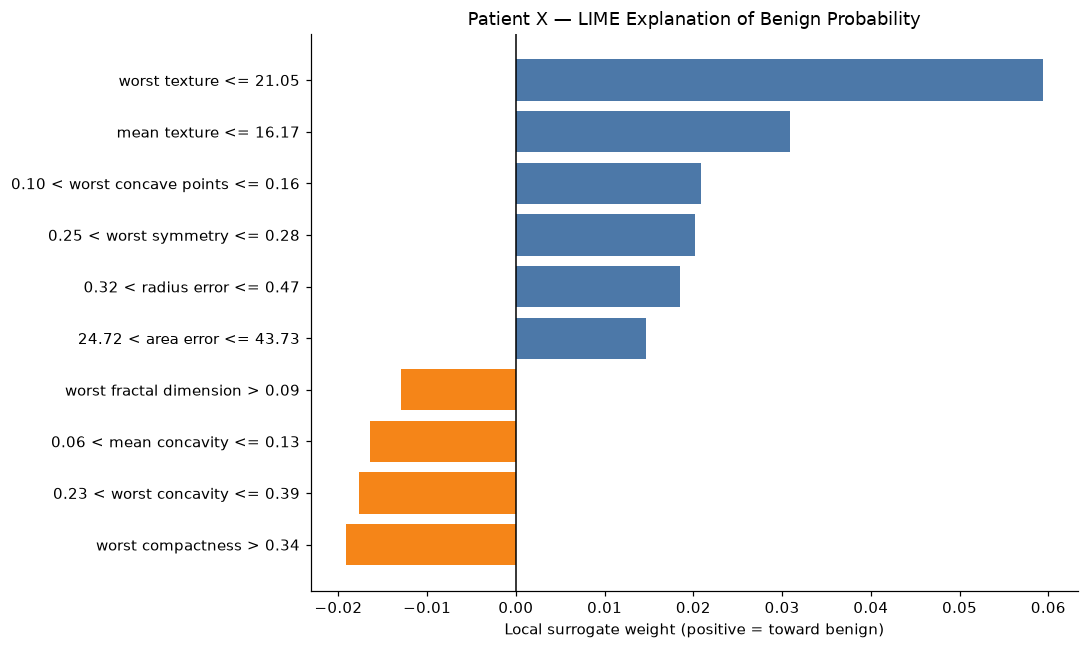

,Check,Value
0,Weighted local R²,0.0584
1,LIME prediction at Patient X,0.6366
2,Random forest benign probability,0.8500
3,Absolute prediction gap,0.2134


In [10]:
LIME_SAMPLES = 5000
LIME_FEATURES = 10
LIME_KERNEL_WIDTH = 0.75 * np.sqrt(X_train_bc.shape[1])

def predict_proba_bc(rows):
    # Restore training feature names when LIME supplies a NumPy array.
    return model_bc.predict_proba(pd.DataFrame(rows, columns=X_train_bc.columns))

def explain_lime_bc(seed):
    explainer = LimeTabularExplainer(
        training_data=X_train_bc.to_numpy(),
        feature_names=list(X_train_bc.columns), class_names=class_names_bc,
        mode="classification", discretize_continuous=True, discretizer="quartile",
        kernel_width=LIME_KERNEL_WIDTH, feature_selection="auto", random_state=seed,
    )
    return explainer.explain_instance(
        focus_instance_bc.iloc[0].to_numpy(), predict_proba_bc,
        labels=(benign_col_bc,), num_features=LIME_FEATURES,
        num_samples=LIME_SAMPLES, distance_metric="euclidean",
    )

lime_patient_bc = explain_lime_bc(RANDOM_STATE)
# Match the condition text to feature IDs supplied by LIME, not substring guesses.
lime_rows_bc = []
for (feature_id, weight), (condition, listed_weight) in zip(
    lime_patient_bc.local_exp[benign_col_bc], lime_patient_bc.as_list(label=benign_col_bc)
):
    np.testing.assert_allclose(weight, listed_weight)
    lime_rows_bc.append({"Feature": X_train_bc.columns[feature_id], "LIME condition": condition,
                         "LIME weight": weight, "Direction": "Toward benign" if weight > 0 else "Away from benign"})
lime_table_bc = pd.DataFrame(lime_rows_bc)
display(lime_table_bc.round(4))

lime_plot_bc = lime_table_bc.sort_values("LIME weight")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(lime_plot_bc["LIME condition"], lime_plot_bc["LIME weight"],
        color=[BENIGN_COLOR if w > 0 else MALIGNANT_COLOR for w in lime_plot_bc["LIME weight"]])
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Patient X — LIME Explanation of Benign Probability")
ax.set_xlabel("Local surrogate weight (positive = toward benign)")
plt.tight_layout()
plt.show()

lime_fit_bc = pd.DataFrame({
    "Check": ["Weighted local R²", "LIME prediction at Patient X", "Random forest benign probability", "Absolute prediction gap"],
    "Value": [lime_patient_bc.score, float(lime_patient_bc.local_pred[0]), patient_benign_bc,
              abs(float(lime_patient_bc.local_pred[0]) - patient_benign_bc)],
})
display(lime_fit_bc.round(4))

LIME's largest positive condition is `worst texture <= 21.05`, followed by `mean texture <= 16.17`. It also assigns a positive weight to Patient X's `worst concave points` interval. These directions partly support SHAP's account. In contrast, high `worst compactness`, the selected `worst concavity` and `mean concavity` intervals, and high `worst fractal dimension` push away from benign in LIME.

The fit check is a major limitation: weighted local R² is only **0.0584**, and the surrogate predicts **0.6366** at Patient X rather than the forest's **0.8500**, a gap of **21.34 percentage points**. I therefore use LIME as a weak qualitative cross-check, not as strong independent confirmation of the forest's reasoning. I keep the documented settings rather than searching for a more favorable explanation.

#### Small LIME stability check

I repeat the same settings with seeds 7 and 21. I check how often each of the original 10 conditions is selected and whether its sign agrees when it is selected. Three runs are a limited sensitivity check, not proof of stability.

In [11]:
lime_runs_bc = {42: lime_patient_bc, 7: explain_lime_bc(7), 21: explain_lime_bc(21)}
stability_rows_bc = []
for feature_id, original_weight in lime_patient_bc.local_exp[benign_col_bc]:
    weights = [dict(run.local_exp[benign_col_bc]).get(feature_id) for run in lime_runs_bc.values()]
    selected = [w for w in weights if w is not None]
    stability_rows_bc.append({"Feature": X_train_bc.columns[feature_id], "Selected runs (of 3)": len(selected),
                              "Same-sign selected runs": sum(np.sign(w) == np.sign(original_weight) for w in selected)})
lime_stability_bc = pd.DataFrame(stability_rows_bc)
display(lime_stability_bc)
display(pd.DataFrame([{"Seed": seed, "Weighted local R²": run.score,
                       "Surrogate prediction": float(run.local_pred[0]),
                       "Gap from forest": abs(float(run.local_pred[0]) - patient_benign_bc)}
                      for seed, run in lime_runs_bc.items()]).round(4))

,Feature,Selected runs (of 3),Same-sign selected runs
0,worst texture,3,3
1,mean texture,3,3
2,worst concave points,2,2
3,worst symmetry,3,3
4,worst compactness,3,3
5,radius error,2,2
6,worst concavity,2,2
7,mean concavity,3,3
8,area error,1,1
9,worst fractal dimension,2,2


,Seed,Weighted local R²,Surrogate prediction,Gap from forest
0,42,0.0584,0.6366,0.2134
1,7,0.0534,0.6390,0.2110
2,21,0.0468,0.5865,0.2635


`worst texture` and `mean texture` are selected with positive signs in all three runs. The negative `mean concavity` and `worst compactness` conditions also appear in all three, so some disagreements with SHAP persist across seeds.

However, not every condition is retained: `area error` appears only once, while `worst concave points` appears twice. Weighted local R² stays low (0.0468–0.0584), and the surrogate's gap from the forest stays large (21.10–26.35 percentage points). Repeating the explanation does not resolve the poor approximation.

### 7. Explanation Comparison and Broader Data Patterns

I compare the leading local features using their directions, not the numerical sizes of the SHAP and LIME values. A missing LIME feature means it was not selected among the 10 displayed conditions; it does not establish that the feature has no effect.

In [12]:
comparison_features_bc = list(dict.fromkeys(
    local_shap_bc.head(6)["Feature"].tolist()
    + local_shap_bc.loc[local_shap_bc["SHAP contribution"] < 0].head(2)["Feature"].tolist()
    + lime_table_bc.head(5)["Feature"].tolist()
))
comparison_bc = local_shap_bc.set_index("Feature").loc[comparison_features_bc].reset_index()[["Feature", "Direction"]].rename(columns={"Direction": "Local SHAP direction"})
comparison_bc = comparison_bc.merge(lime_table_bc[["Feature", "LIME condition", "Direction"]], on="Feature", how="left")
comparison_bc = comparison_bc.rename(columns={"Direction": "LIME direction"})
comparison_bc["Interpretation"] = np.where(comparison_bc["LIME direction"].isna(), "Not in LIME top 10",
    np.where(comparison_bc["Local SHAP direction"] == comparison_bc["LIME direction"], "Directional agreement", "Directional difference"))
display(comparison_bc.fillna("Not selected"))

,Feature,Local SHAP direction,LIME condition,LIME direction,Interpretation
0,worst texture,Toward benign,worst texture <= 21.05,Toward benign,Directional agreement
1,worst concave points,Toward benign,0.10 < worst concave points <= 0.16,Toward benign,Directional agreement
2,worst area,Toward benign,Not selected,Not selected,Not in LIME top 10
3,mean concavity,Toward benign,0.06 < mean concavity <= 0.13,Away from benign,Directional difference
4,worst radius,Toward benign,Not selected,Not selected,Not in LIME top 10
5,mean texture,Toward benign,mean texture <= 16.17,Toward benign,Directional agreement
6,worst perimeter,Away from benign,Not selected,Not selected,Not in LIME top 10
7,worst fractal dimension,Away from benign,worst fractal dimension > 0.09,Away from benign,Directional agreement
8,worst symmetry,Toward benign,0.25 < worst symmetry <= 0.28,Toward benign,Directional agreement
9,worst compactness,Toward benign,worst compactness > 0.34,Away from benign,Directional difference


Both methods support benign through `worst texture`, `mean texture`, and `worst concave points`. Both assign a negative direction to `worst fractal dimension`. However, `mean concavity` and `worst compactness` are positive in SHAP and negative in LIME.

I checked that both methods explain class 1 and that LIME conditions are matched using feature IDs. The difference therefore is not a swapped class label or a feature-name mix-up. SHAP attributes the forest's output relative to a fixed background; LIME approximates perturbed predictions using discretized conditions. Its very low local R² means I cannot treat the disagreement as equally reliable evidence about the forest. Correlations and the different reference comparisons also make a one-to-one interpretation inappropriate.

#### Patient X compared with the training classes

I select the two strongest positive and two strongest negative local SHAP features. This keeps evidence on both sides in the distribution comparison. I use training cases only and normalized densities so the larger benign class does not automatically produce taller bars.

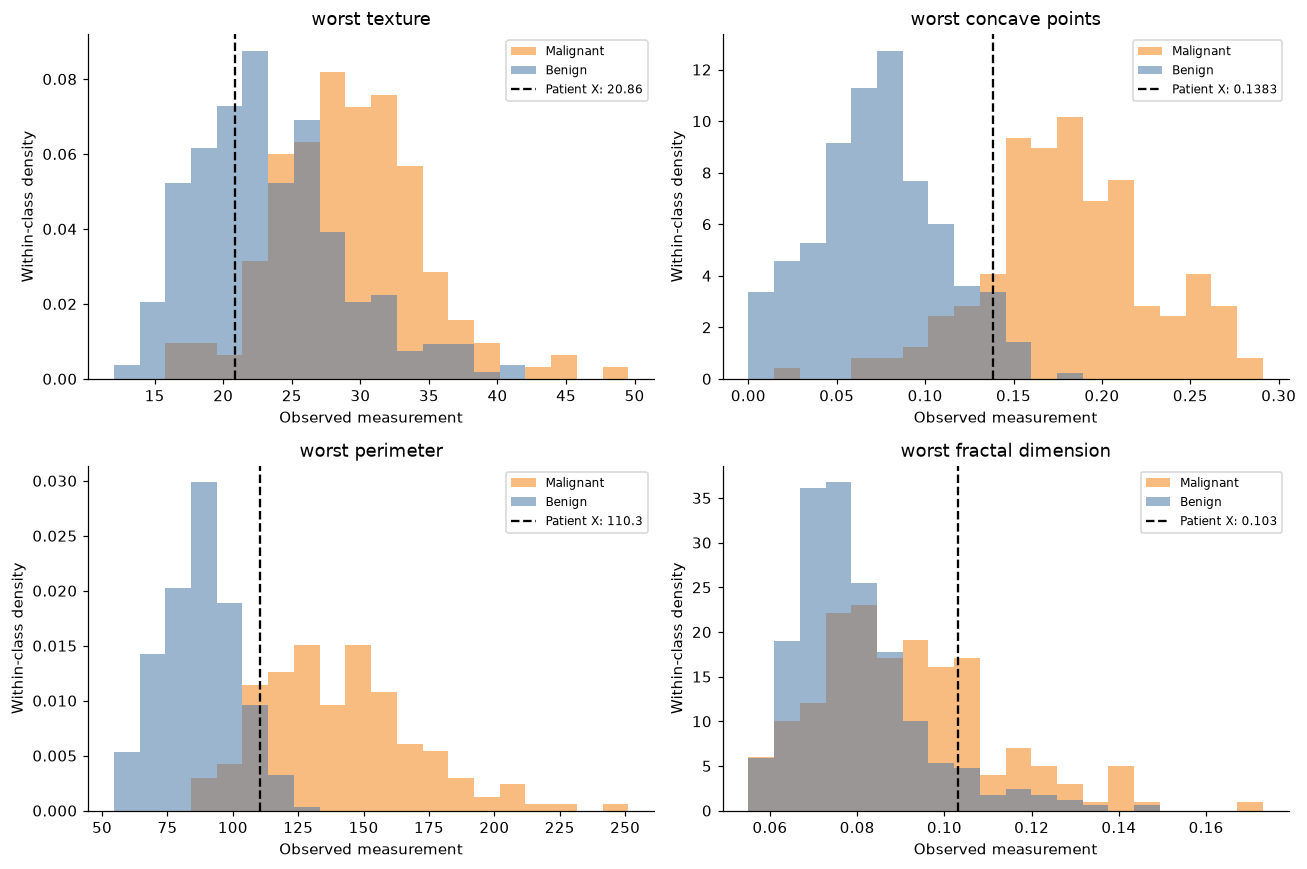

,Feature,Class,Patient X,Class median,Class Q1,Class Q3,Percent at or below Patient X
0,worst texture,malignant,20.8600,29.4100,25.8400,32.0600,4.1420
1,worst texture,benign,20.8600,22.7450,19.3825,26.4000,35.6643
2,worst concave points,malignant,0.1383,0.1785,0.1530,0.2091,15.3846
3,worst concave points,benign,0.1383,0.0743,0.0509,0.0974,94.7552
4,worst perimeter,malignant,110.3000,139.2000,117.7000,158.8000,14.7929
5,worst perimeter,benign,110.3000,86.8700,78.3200,97.0175,94.0559
6,worst fractal dimension,malignant,0.1030,0.0886,0.0762,0.1024,76.9231
7,worst fractal dimension,benign,0.1030,0.0770,0.0701,0.0849,92.6573


In [13]:
support_features_bc = local_shap_bc.loc[local_shap_bc["SHAP contribution"] > 0].head(2)["Feature"].tolist()
opposing_features_bc = local_shap_bc.loc[local_shap_bc["SHAP contribution"] < 0].head(2)["Feature"].tolist()
selected_features_bc = support_features_bc + opposing_features_bc
assert len(selected_features_bc) == 4

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
distribution_rows_bc = []
for ax, feature in zip(axes.ravel(), selected_features_bc):
    patient_value = float(focus_instance_bc.at[0, feature])
    bins = np.histogram_bin_edges(X_train_bc[feature], bins=20)
    for label, color in [(MALIGNANT, MALIGNANT_COLOR), (BENIGN, BENIGN_COLOR)]:
        values = X_train_bc.loc[y_train_bc == label, feature]
        ax.hist(values, bins=bins, density=True, alpha=0.55, color=color, label=class_names_bc[label].title())
        distribution_rows_bc.append({"Feature": feature, "Class": class_names_bc[label], "Patient X": patient_value,
                                     "Class median": values.median(), "Class Q1": values.quantile(.25),
                                     "Class Q3": values.quantile(.75), "Percent at or below Patient X": 100 * (values <= patient_value).mean()})
    ax.axvline(patient_value, color="black", linestyle="--", linewidth=1.5, label=f"Patient X: {patient_value:g}")
    ax.set_title(feature)
    ax.set_xlabel("Observed measurement")
    ax.set_ylabel("Within-class density")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
distribution_summary_bc = pd.DataFrame(distribution_rows_bc)
display(distribution_summary_bc.round(4))

`worst texture = 20.86` is within the benign training class's middle 50% (19.3825–26.4000), but only 4.14% of malignant training cases have a value this low or lower. This is the clearest broader-data support for Patient X's benign classification.

`worst concave points = 0.1383` is more mixed. It is below the malignant first quartile (0.1530), but it is also above 94.76% of benign training values. Its positive SHAP contribution does not mean this measurement is typical of benign cases. The model's combined prediction and its background comparison differ from looking at this one distribution.

The two opposing features add further caution. `worst perimeter = 110.3` lies above 94.06% of benign values and below the malignant first quartile (117.7), placing it between the class centers with overlap. `worst fractal dimension = 0.1030` exceeds 92.66% of benign values and sits close to the malignant third quartile (0.1024). These plots support a mixed profile, not a claim that all of Patient X's measurements look benign. The percentiles describe the training distributions; they are not probabilities of malignancy.

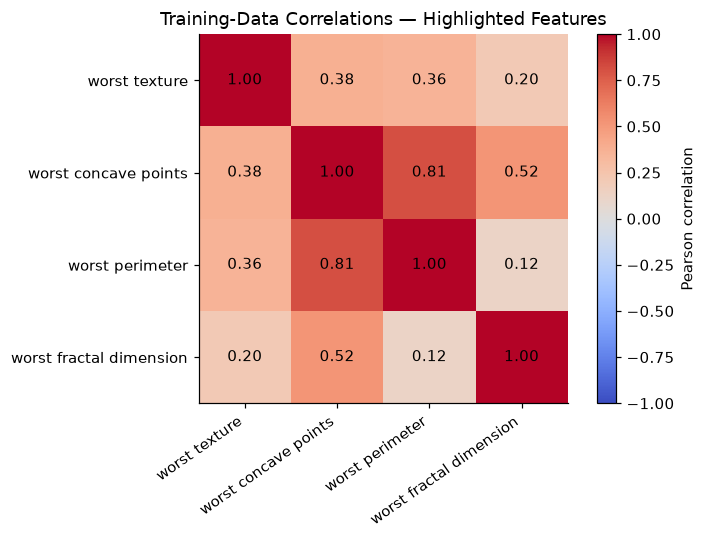

,worst texture,worst concave points,worst perimeter,worst fractal dimension
worst texture,1.000,0.380,0.357,0.204
worst concave points,0.380,1.000,0.807,0.518
worst perimeter,0.357,0.807,1.000,0.120
worst fractal dimension,0.204,0.518,0.120,1.000


In [14]:
selected_corr_bc = X_train_bc[selected_features_bc].corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(selected_corr_bc, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(4), selected_features_bc, rotation=35, ha="right")
ax.set_yticks(range(4), selected_features_bc)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{selected_corr_bc.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Training-Data Correlations — Highlighted Features")
plt.tight_layout()
plt.show()
display(selected_corr_bc.round(3))

`worst concave points` and `worst perimeter` have a strong training correlation of **0.807**. `worst concave points` also correlates with `worst fractal dimension` at **0.518**. I should not present these measurements as independent votes for or against the defense.

The interventional SHAP setup and LIME perturbations can evaluate combinations that do not preserve the observed feature dependence. This limits how literally I interpret each attribution as a separate effect. The correlation plot also does not establish causation or show all dependencies among the 30 features.

### 8. Defense Argument and Limitations

#### What supports the defense?

The random forest classified Patient X as benign primarily because positive contributions from `worst texture`, `worst concave points`, `worst area`, and other features outweighed the negative contributions. SHAP reproduces the 0.85 benign probability from its 0.607 baseline. LIME also highlights low texture measurements in the benign direction, and the training distributions show that Patient X's worst texture is more consistent with common benign measurements than common malignant measurements.

My strongest defense is therefore that the classification has a traceable basis in the model's learned patterns. The 96.49% test accuracy supplies context, but the individual explanation and distribution comparison provide the more specific evidence for Patient X.

#### What weakens the defense?

The model missed 3 of 43 malignant test cases. Patient X also has opposing SHAP contributions from worst perimeter and worst fractal dimension, and the distribution plots show overlap rather than an entirely benign-looking profile. LIME has low local fidelity and disagrees with SHAP on some features, so I cannot claim that two strong explanations independently confirm the decision. Correlated measurements, one train/test split, and one SHAP background sample further limit generalization. I have not evaluated probability calibration or validated a clinical referral threshold.

#### What conclusion is justified?

The evidence supports a limited defense of how the model arrived at its benign classification. It does not establish that the prediction was medically correct. The scenario's later malignant diagnosis remains an adverse outcome that the explanation does not remove.

The starter prints “Benign → No Biopsy,” but it does not separately implement or validate a biopsy-referral policy. The dataset itself uses measurements from fine needle aspirate images, so this exercise cannot validate a real pre-biopsy decision process. I can explain the classification without claiming that withholding a biopsy was justified.

#### Likely prosecution challenge

**“Even if we can explain the prediction, why should we consider the decision defensible?”**

My response is that a traceable prediction is defensible only in a narrower sense: the model used learned patterns that can be examined, and the low texture measurement has support in the training data. That is evidence against an arbitrary classification. It is not enough to defend the downstream action. The missed malignant cases, Patient X's mixed measurements, and the lack of a validated referral policy prevent that stronger claim.

### 9. Notes for the Group Discussion

For the five-minute group argument, I would use this sequence:

| Time | Evidence to present | Main point |
| --- | --- | --- |
| 0:00–0:45 | Scenario and prediction table | Define the limited defense; the forest predicts 85% benign. |
| 0:45–1:30 | Confusion matrix | Accuracy is 96.49%, but 3 of 43 malignant cases are missed. |
| 1:30–2:30 | Global importance and local SHAP waterfall | Explain the leading model features and the contributions for Patient X. |
| 2:30–3:15 | LIME plot and fit check | Texture directions agree, but local R² is only 0.0584. |
| 3:15–4:15 | Training distributions | Worst texture supports the defense; other measurements show a mixed profile. |
| 4:15–5:00 | Qualified conclusion | The classification is explainable; the no-biopsy action is not validated here. |

For the two-minute rebuttal, I would acknowledge the adverse outcome first, then distinguish explaining the classification from validating its consequences. I would not describe 85% as a clinical guarantee, count correlated features as independent evidence, or hide LIME's poor fit. These are notes to combine with teammates' findings during the group phase.

#### Reproducibility check

The checks below confirm the original split/model settings, feature order, class selection, SHAP reconstruction, and agreement between LIME's prediction wrapper and the forest. The notebook is executed from a fresh `ids_ml` kernel with the package versions printed above.

In [15]:
assert len(X_train_bc) == 455 and len(X_test_bc) == 114
assert set(X_train_bc.index).isdisjoint(X_test_bc.index)
assert set(background_bc.index).issubset(X_train_bc.index)
assert model_bc.random_state == 42 and model_bc.n_estimators == 100
assert model_bc.classes_[benign_col_bc] == 1
assert focus_instance_bc.columns.equals(X_train_bc.columns)
assert len(local_shap_bc) == 30
assert benign_col_bc in lime_patient_bc.local_exp
assert np.isfinite(shap_patient_bc.values).all()
np.testing.assert_allclose(shap_reconstructed_bc, patient_benign_bc, atol=1e-6, rtol=0)
np.testing.assert_allclose(predict_proba_bc(focus_instance_bc.to_numpy())[0], patient_proba_bc)
print("All Case 2 consistency checks passed.")

All Case 2 consistency checks passed.


#### Sources

The scenario, Patient X values, and original model come from the supplied `machine_learning_court.ipynb`. The submission requirements come from `instructions.docx`. The provided linear regression notebook guides the organization and writing style.

- [Scikit-learn breast cancer dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)
- [Tree SHAP configuration and output scale](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html)
- [SHAP global bar importance](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html)
- [SHAP waterfall plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html)
- [LIME tabular explanation and fit diagnostics](https://lime-ml.readthedocs.io/en/latest/lime.html)